# Tutorial 12 - Restricted Boltzmann Machines

The aim of this tutorial is to gain acquaintance with generative models, in particular implementing energy based models up to Restriced Boltzmann Machines (RBMs). In order to do so, we will apply those techniques to real protein data! 

This tutorial owes full credits to the authors of the following article regarding the data and methodologies suggested:

Russ, W.P., Figliuzzi, M., Stocker, C., Barrat-Charlaix, P., Socolich, M., Kast, P., Hilvert, D., Monasson, R.,
Cocco, S., Weigt, M. and Ranganathan, R., 2020. An evolution-based model for designing chorismate mutase
enzymes. Science, 369(6502), pp.440-445

The data used in this tutorial are protein-sequence data, which have been elaborated by the team of the authors above together with a number of experimental biologists.

Data are provided as multiple-sequence alignments (MSA), i.e. as rectangular arrays, where each row is a
protein sequence, each column an aligned position. The entries are either one of the 20 natural amino acids
{A, C, D, E, F, G, H, I, K, L, M, N, P, Q, R, S, T, V, W, Y} or the alignment gap “−”, i.e. the variables are 21-state categorical
variables. Each protein is composed of $L=96$ amino acids (or alignment gap). The format of the datafiles is the so-called Fasta file format:

> \> sequence 1 functional true
−TSENPLLALREKISALDEKLLALLAERRELAVEVGKAKLLSHRPVRDE...

> \> sequence 2 functional false
VENNDKINKLRTQIDPLDHKIIEDLGKRMKIADEIGELKKEQNVAVLQAK...


The line starting with “>” is a comment line, containing arbitrary information about the following sequence. In
our case it is just a protein identifier (simplified in our files) and, more importantly, an information if the protein is
functioning or not in an experimental screen. The next line(s) until the next “>” contain(s) one aligned amino-acid
sequence.
There are two data files. The first consists of so-called "natural sequences", i.e. existing proteins whose functionality to a certain enzime (true or false label) have been tested in the lab. The second file contains the so-called "artificial
sequences", which were generated by a generative model learned on the natural data in MSA format. Artificial sequences are still really-existing sequences, but they have been sampled from a distribution generated from the natural ones. Such distribution is not given to you. In both cases, a label is attached to the proteins (true or false, i.e. 1 or -1) depending their functionality with respect to a certain enzime in a water solution.

Both files have the same form, both files contain the functionality, which was determined in in vivo experiments.

In [66]:
#import packages
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
import seaborn as sns
from collections import defaultdict
from tqdm import tqdm


In this tutorial, as in any real-world application, we will first investigate briefly the dataset. In particular, we will first one-hot encode the protein sequences, which is a standard technique for analysing protein datasets. Then, we will visualise the spatial distribution of the protein sequences (natural/artificial , functioning/non-functioning) onto the first two principal components. 

Once this preliminary analysis is done, we will move to the real tutorial part, i.e. generate new proteins sampled from a distribution that is as coherent as possible to the one of the original data. 

## One-hot encoding

Task 1: One-hot encoding of protein sequence data. Categorical variables are frequently represented in one-hot encoding, i.e. as vectors containing one entry equal to 1, and all the other equal to 0. In the case of protein data, a little variant in useful: you may use a 20-dimensional representation with the amino acids being mapped as A->(1,...,0),C->(0,1,...,0),...,Y->(0,...,0,1), while the gap '-' is mapped to the zero vector, - ->(0,...,0). Note that the one-hot encoding blows up the feature vectors from L=96 categorical variables (the lenght of each protein sequence) to 20L=1920 binary variables, but the numerical treatment is easies.

One-hot encoding, in this case, allows not to introduce any geometric ordering among our categorical data.

In [67]:
def parse_fasta_file(filepath):
    # Define the amino acids and the mapping to one-hot vectors
    amino_acids = 'ACDEFGHIKLMNPQRSTVWY'
    aa_to_onehot = {aa: [1 if aa == a else 0 for a in amino_acids] for aa in amino_acids} #put a 1 in the position of the amino acid read in the file and 19 zeros
    aa_to_onehot['-'] = [0] * 20  # the alignment gap is represented by a 20-zero component vector

    onehot_sequences = []
    labels = []

    with open(filepath, 'r') as file:
        while True:
            header = file.readline().strip()
            if not header:
                break

            # Read the two lines of the sequence and concatenate them because of the structure of the file
            sequence = file.readline().strip() + file.readline().strip()
            file.readline()  # Skip the empty line

            # Extract the label from the header True or False
            label = 1 if header[-4:] == 'true' else 0
            labels.append(label)

            # One-hot encode the sequence
            onehot_seq = []
            for aa in sequence:
                onehot_seq.extend(aa_to_onehot.get(aa, [0] * 20))

            onehot_sequences.append(onehot_seq)

    return np.array(onehot_sequences), np.array(labels)

# File paths that has to be changed
nat_filepath = './MSA_nat_with_annotation.faa'
art_filepath = './MSA_art.faa'

#natural sequences
onehot_nat, labels_nat = parse_fasta_file(nat_filepath)

# artificial sequences
onehot_art, labels_art = parse_fasta_file(art_filepath)

In [68]:
# Checking the dimensions of the output arrays for the artificial sequences and it's correct
onehot_art.shape, labels_art.shape

((1003, 1920), (1003,))

In [69]:
# Checking the dimensions of the output arrays for the artificial sequences and it's correct
onehot_nat.shape, labels_nat.shape

((1130, 1920), (1130,))

In [70]:
# Now, let's calculate the number of functioning and not functioning proteins in both datasets as well as the fraction of functioning proteins.

def analyze_functionality(labels):
    total = len(labels)
    functioning = sum(labels)
    not_functioning = total - functioning
    fraction_functioning = functioning / total *100
    return functioning, not_functioning, fraction_functioning

functioning_nat, not_functioning_nat, fraction_nat = analyze_functionality(labels_nat)
functioning_art, not_functioning_art, fraction_art = analyze_functionality(labels_art)

functioning_nat, not_functioning_nat, fraction_nat, functioning_art, not_functioning_art, fraction_art

print(f"Number of functioning proteins in the natural dataset={functioning_nat}\nNumber of not-functioning proteins in the natural dataset={not_functioning_nat}")
print(f"Fraction of functioning proteins in the natural dataset={fraction_nat}%")
print(f"Number of functioning proteins in the artificial dataset={functioning_art}\nNumber of not-functioning proteins in the artificial dataset={not_functioning_art}")
print(f"Fraction of functioning proteins in the artificial dataset={fraction_art}%")

Number of functioning proteins in the natural dataset=423
Number of not-functioning proteins in the natural dataset=707
Fraction of functioning proteins in the natural dataset=37.43362831858407%
Number of functioning proteins in the artificial dataset=499
Number of not-functioning proteins in the artificial dataset=504
Fraction of functioning proteins in the artificial dataset=49.750747756729815%


## Dimensionality reduction and visualization of sequence space

Task 2: Dimensional reduction and visualization of sequence space. 

Use PCA of the natural data in one-hot encoding, to determine the frst few principle components (PCs) of the dataset. Project sequences onto the first two PCs and represent graphically the dimensionally reduced data. What do you observe? Color sequences according to their functionality. Are functional and non-functional sequences well sperarated in PCA space? Project also the generated sequences onto the PCs determined from the natural data. Do they occupy a similar region in (dimensionally reduced) sequence space?

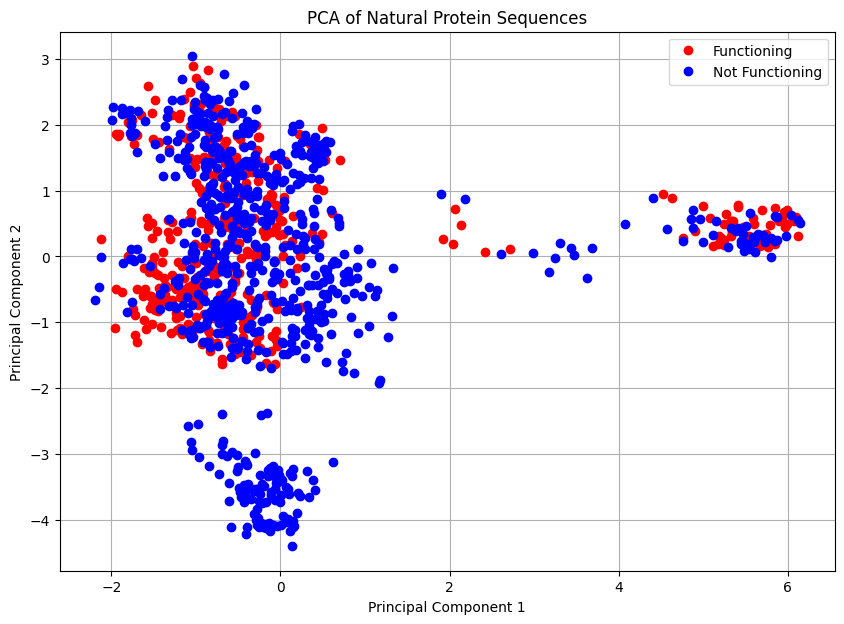

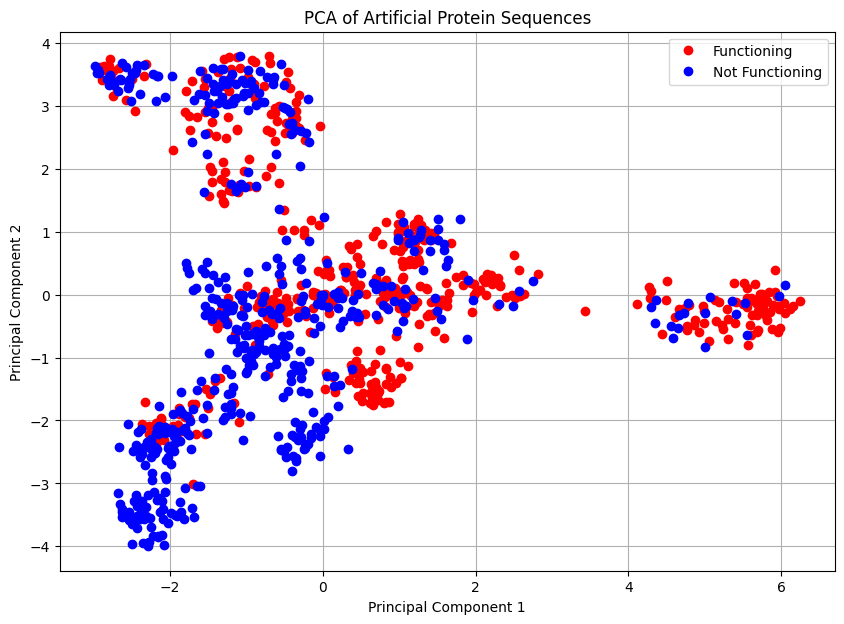

In [71]:
# Write you codes here and below to answer the questions in the tutorial
pca = PCA(n_components=2)
pca_nat = pca.fit_transform(onehot_nat)

plt.figure(figsize=(10, 7))
plt.plot(pca_nat[labels_nat == 1, 0], pca_nat[labels_nat == 1, 1], 'ro', label='Functioning')
plt.plot(pca_nat[labels_nat == 0, 0], pca_nat[labels_nat == 0, 1], 'bo', label='Not Functioning')
plt.title('PCA of Natural Protein Sequences')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid()
plt.show()

pca_art = pca.fit_transform(onehot_art)
plt.figure(figsize=(10, 7))
plt.plot(pca_art[labels_art == 1, 0], pca_art[labels_art == 1, 1], 'ro', label='Functioning')
plt.plot(pca_art[labels_art == 0, 0], pca_art[labels_art == 0, 1], 'bo', label='Not Functioning')
plt.title('PCA of Artificial Protein Sequences')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid()
plt.show()

The first two components do not separate well between functional and non-functional portains.

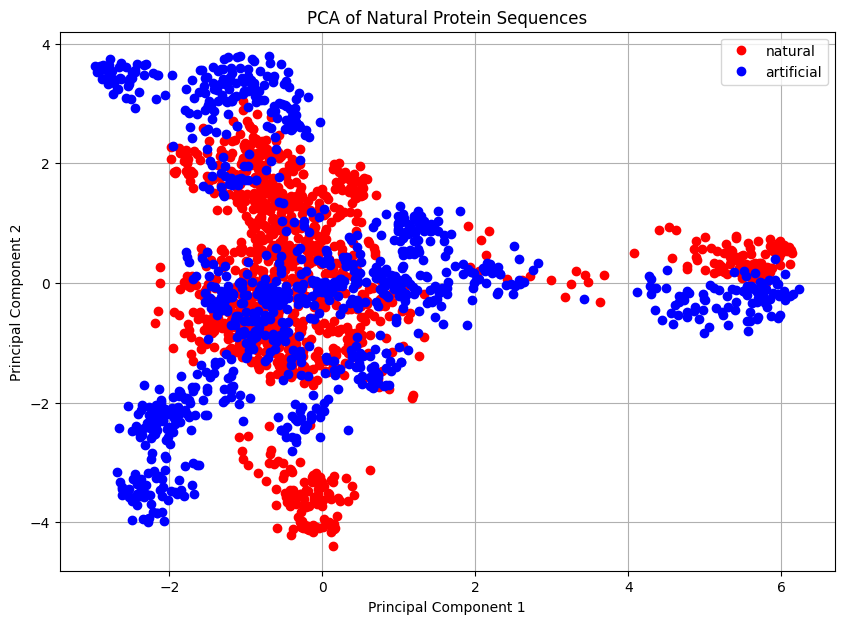

In [72]:
plt.figure(figsize=(10, 7))
plt.plot(pca_nat[:, 0], pca_nat[:, 1], 'ro', label='natural')
plt.plot(pca_art[:, 0], pca_art[:, 1], 'bo', label='artificial')
plt.title('PCA of Natural Protein Sequences')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid()
plt.show()

## Exercise 1: Independent Fields Model

**Theoretical Background**

In this exercise, we consider the simplest generative model for our protein sequences: an **independent fields model** (also referred to as the independent site model). The key assumption here is that each amino acid position in the protein sequence is statistically independent of the others. 

Given a multiple sequence alignment (MSA) of natural protein sequences, we can estimate the frequency of each amino acid at each position. These frequencies can be interpreted as probabilities. Thus, the probability distribution over a full protein sequence $ x = (x_1, x_2, \ldots, x_L) $ of length $L=96$ can be factorized as:


$$ p_{\text{ind}}(x) = \prod_{i=1}^{L} p(x_i) $$

Here, $ p(x_i) $ is the probability of observing a particular amino acid at position $ i $, estimated from the empirical frequencies in the natural data. Since we treat each position independently, there are no couplings or interactions between positions.

We can rephrase this problem in energy terms and statistical physics concepts. Please refer yourself to the lecture notes of the course.

**Energy Function:**

In the independent fields model, we assume that each position is independent of the others. Hence, the energy function includes only local fields $h_i^a$ and no couplings:

$$
E_{\text{ind}}(x) = -\sum_{i=1}^{L} \sum_{a=1}^{q} h_i^a x_i^a
$$

Here, $h_i^a$ is a scalar parameter associated with amino acid $a$ at position $i$. Here $q=20$ is the number of aminoacids (no aligning gap considered) and $x_i^a =1$ is aminoacid $a$ (among the $20$ possible ones) is at position $i$ and zero otherwise. 

**Probability Distribution:**

The probability of observing sequence $x$ is given by the Boltzmann distribution:

$$
p_{\text{ind}}(x) = \frac{1}{Z_{\text{ind}}}\exp\left(-E_{\text{ind}}(x)\right)
$$

where $Z_{\text{ind}}$ is the partition function ensuring normalization.

**Maximum Likelihood and Matching Averages:**

We have empirical averages computed from the data (the natural MSA):

$$
\langle x_i^a \rangle_{\text{data}} = \frac{1}{N}\sum_{\mu=1}^{N} x_{i,\mu}^a
$$

where $\mu$ indexes over the $N$ natural protein sequences.

The model averages are defined as:

$$
\langle x_i^a \rangle_{\text{model}} = \sum_x x_i^a p_{\text{ind}}(x)
$$

Maximum likelihood estimation involves adjusting the parameters $h_i^a$ to match the empirical and model averages:

$$
\langle x_i^a \rangle_{\text{data}} = \langle x_i^a \rangle_{\text{model}}
$$

**Gradient Ascent on $h_i^a$:**

The gradient of the log-likelihood with respect to $h_i^a$ is proportional to the difference between the data and model averages:

$$
\frac{\partial \log \mathcal{L}}{\partial h_i^a} \propto \langle x_i^a \rangle_{\text{data}} - \langle x_i^a \rangle_{\text{model}}
$$

We can use gradient ascent updates:

$$
h_i^a \leftarrow h_i^a + \gamma \left(\langle x_i^a \rangle_{\text{data}} - \langle x_i^a \rangle_{\text{model}}\right)
$$

Here, $\gamma$ is the learning rate. The model averages $\langle x_i^a \rangle_{\text{model}}$ can be approximated via sampling from $p_{\text{ind}}(x)$.

In this first excercise we will do a simple analysis divided in the following points. Please write the code for the 4 points below.

**Tasks:**
1. **Compute the single-site frequencies** from the natural protein sequences.
2. **Use these frequencies** to define a probability distribution over amino acids at each position.
3. **Generate new protein sequences** by **sampling from this independent site distribution**.
4. **Compare the generated sequences** to the natural sequences by projecting both sets onto principal component space using PCA. Use the first two principal components to have a 2D plot.

**Hints:**
- After computing the frequency of each amino acid at each site, ensure that they sum to 1 to form a proper probability distribution. In particular the alignment gap, which is assigned the full zeroes vector and thus is not considered in the energy function as it always contributes $0$, is assigned a frequency on each site given by one minus the frequencies of all other $q=20$ aminoacids in order to ensure normalization of the frequency distribution.
- To sample a new sequence, draw one amino acid per position independently according to the computed probabilities.

**Code Hint:**
- Use `np.sum` and `np.any` over the one-hot encoded array to count occurrences.
- Use `random.choices` with the computed probabilities to sample amino acids per site.

**Expected Outcome:**
You will see that while the generated sequences may occupy a similar region in PCA space as the natural ones, the assumption of independence fails to capture the full complexity of the natural distribution. The generated sequences often lack important co-evolutionary patterns present in the natural data.


In [73]:
#Independent fields model

#We start from an independent fields potts model. This is the simples model you can do for a generative model.
#Here we claim that the 96 sites are all independent and we place in each of them 21 local fields (for each aminoacid and for the alignment gap).
#In the end, we just have to compute the frequencies of each aminoacid in each site, ensure normalization and sample from this distribution.
#In this section we only use natural sequences because I do not want any bias from the pdf of the artificial ones.


# Write your code here to answer the 4 questions of the Tasks section above.

def compute_frequencies(onehot_sequences):
    num_sequences, seq_length = onehot_sequences.shape
    num_amino_acids = 20  # 20 amino acids + gap
    freqs = np.zeros((seq_length // num_amino_acids, num_amino_acids))

    for i in range(seq_length // num_amino_acids):
        site_data = onehot_sequences[:, i * num_amino_acids:(i + 1) * num_amino_acids]
        freqs[i] = np.sum(site_data, axis=0) / num_sequences

    return freqs

def probability_distribution(onehot_sequences):
    freqs = compute_frequencies(onehot_sequences)
    return freqs / np.sum(freqs, axis=1, keepdims=True)

def sample_sequences(onehot_sequences, num_samples):
    probs = probability_distribution(onehot_sequences)
    assert np.allclose(np.sum(probs, axis=1), 1), "Probabilities do not sum to 1"
    seq_length = probs.shape[0]
    num_amino_acids = probs.shape[1]
    sampled_sequences = np.zeros((num_samples, seq_length * num_amino_acids), dtype=int)

    for i in range(num_samples):
        for j in range(seq_length):
            aa = np.random.choice(num_amino_acids, p=probs[j])
            sampled_sequences[i, j * num_amino_acids + aa] = 1

    return sampled_sequences

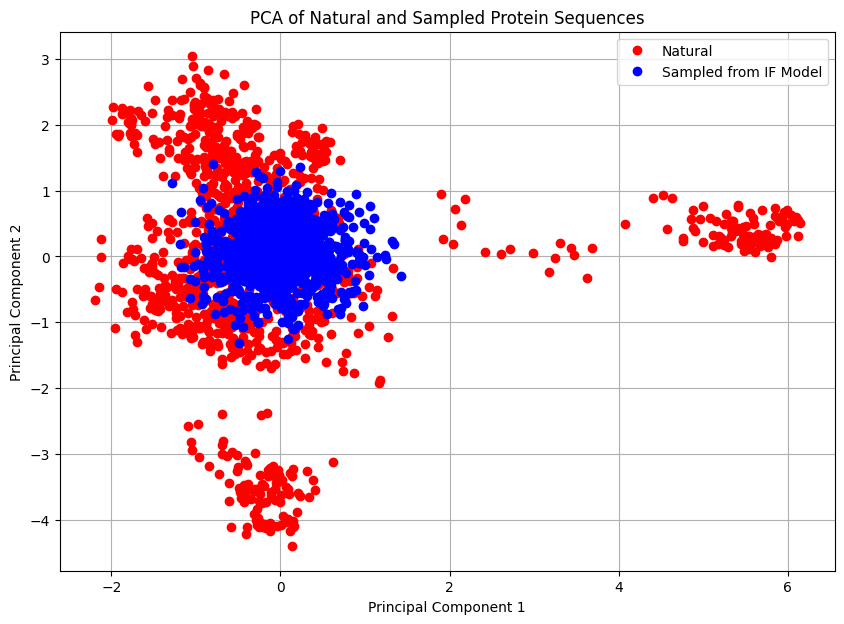

In [74]:
sample_seq = sample_sequences(onehot_nat, 1000)

pca_2d = PCA(n_components=2)
pca_nat_2d = pca_2d.fit_transform(onehot_nat)
pca_sampled_2d = pca_2d.transform(sample_seq)

plt.figure(figsize=(10, 7))
plt.plot(pca_nat_2d[:, 0], pca_nat_2d[:, 1], 'ro', label='Natural')
plt.plot(pca_sampled_2d[:, 0], pca_sampled_2d[:, 1], 'bo', label='Sampled from IF Model')
plt.title('PCA of Natural and Sampled Protein Sequences')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid()
plt.show()

In [75]:
#Now we implement a Boltzmann machine and a restricted boltzmann machine, installing all the packages needed.
from sklearn import linear_model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import BernoulliRBM
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from scipy.ndimage import convolve
from sklearn import datasets
from sklearn.preprocessing import minmax_scale
from sklearn.neural_network import BernoulliRBM
from sklearn.base import clone


## Exercise 2: Boltzmann Machine (Including Couplings $J_{ij}$)

**Theoretical Background**

In the previous exercise, we assumed that each position is independent. However, real protein sequences often display correlated substitutions: changes at one position may depend on changes at another. To capture these correlations, we extend the independent model to a **Boltzmann Machine**, which includes both fields $ h_i $ and couplings $ J_{ij} $:

$$
E(x) = -\sum_{i=1}^{L}\sum_{a=1}^{q} h_i^a x_i^a - \sum_{1 \leq i < j \leq L}\sum_{a=1}^{q}\sum_{b=1}^{q} J_{ij}^{ab} x_i^a x_j^b
$$

Here:
- $ x_i^a $ is a one-hot variable indicating the presence of amino acid a at position i.
- $ h_i^a $ are local fields for each amino acid a at position  i .
- $ J_{ij}^{ab} $ are couplings between amino acids a at position i and b at position j.
- $L=96$: sequence length.
- $q=20$: number of amino acids.

By introducing couplings, this model can capture pairwise correlations between positions. This model is exactly the Boltzmann machine you saw in the lectures. The only difference is that here our x variables are not ising spins but "Potts" spins, as they can represent the 20 amino acids and the alignment gap (so 21 values in total instead of $\pm 1$). This is why we add the index $a$ in $x_i ^a$, to specify not only the position in the protein sequence $i$ but also the type of aminoacid $a$. Apart from this small generalization, the model is unchanged.



**Probability Distribution:**

The probability of observing sequence x is given by the Boltzmann distribution:

$$
p_{\text{pair}}(x) = \frac{1}{Z_{\text{pair}}}\exp\left(-E_{\text{pair}}(x)\right)
$$

where $Z_{\text{pair}} $ is the partition function ensuring normalization.

**Maximum Likelihood and Matching Averages:**

We have empirical averages computed from the data (the natural MSA):

$$
\langle x_i^a \rangle_{\text{data}} = \frac{1}{N}\sum_{\mu=1}^{N} x_{i,\mu}^a
$$

where $ \mu $ indexes over the $ N $ natural protein sequences.

The model averages are defined as:

$$
\langle x_i^a \rangle_{\text{model}} = \sum_x x_i^a p_{\text{pair}}(x), \quad
\langle x_i^a x_j^b \rangle_{\text{model}} = \sum_x x_i^a x_j^b p_{\text{pair}}(x)
$$

Maximum likelihood estimation involves adjusting the parameters \( h_i^a \) and \( J_{ij}^{ab} \) to match the empirical and model averages:

$$
\langle x_i^a \rangle_{\text{data}} = \langle x_i^a \rangle_{\text{model}}, \quad
\langle x_i^a x_j^b \rangle_{\text{data}} = \langle x_i^a x_j^b \rangle_{\text{model}}
$$

**Gradient Ascent on $h_i^a$ and $J_{ij}^{ab}$:**

The gradients of the log-likelihood are:

$$
\frac{\partial \log \mathcal{L}}{\partial h_i^a} \propto \langle x_i^a \rangle_{\text{data}} - \langle x_i^a \rangle_{\text{model}}
$$

$$
\frac{\partial \log \mathcal{L}}{\partial J_{ij}^{ab}} \propto \langle x_i^a x_j^b \rangle_{\text{data}} - \langle x_i^a x_j^b \rangle_{\text{model}}
$$

We perform gradient ascent updates:

$$
h_i^a \leftarrow h_i^a + \gamma \left(\langle x_i^a \rangle_{\text{data}} - \langle x_i^a \rangle_{\text{model}}\right)
$$

$$
J_{ij}^{ab} \leftarrow J_{ij}^{ab} + \gamma \left(\langle x_i^a x_j^b \rangle_{\text{data}} - \langle x_i^a x_j^b \rangle_{\text{model}}\right)
$$

Here, $ \gamma $ is the learning rate. The model averages $\langle \cdot \rangle_{\text{model}}$ can be approximated via sampling from $p_{\text{pair}}(x)$. The empirical averages and covariances can be easily computed directly from the one-hot encoded data. 



**Tasks:**
1. **Implement the pairwise Potts model** for the protein sequences.
2. **Estimate the parameters $h_i^a$ and $J_{ij}^{ab} $** using maximum likelihood:
$$
   h_i^a \leftarrow h_i^a + \gamma(\langle x_i^a \rangle_{\text{data}} - \langle x_i^a \rangle_{\text{model}}), \quad
   J_{ij}^{ab} \leftarrow J_{ij}^{ab} + \gamma(\langle x_i^a x_j^b \rangle_{\text{data}} - \langle x_i^a x_j^b \rangle_{\text{model}})
$$
3. **Use Monte Carlo sampling (e.g., Metropolis)** to estimate model expectations $\langle \cdot \rangle_{\text{model}}$.
4. **Generate new protein sequences** by sampling from the learned model.
5. **Compare the generated sequences** to the natural sequences in PCA space and **analyze if including couplings improves the generative model** over the independent fields model.

**Hints:**
- Approximate the model expectations using Contrastive Divergence (CD-1) to approximate gradients. This makes the computation tractable and speed up Monte Carlo. This is already done since it is just a numerical trick that you may find useful in your future career.
- Carefully initialize the parameters h and J and update them iteratively.
- Consider small learning rates and multiple epochs to reach a good approximation.

**Code Hint :**
- Use `np.einsum` for efficient correlation computation.
- Use small learning rates and multiple epochs.
- Implement a simple  Monte Carlo step per update (CD-1).
- Once trained, generate sequences from the learned model and compare via PCA.

**Approximating Model Averages:**

To approximate $\langle \cdot \rangle_{\text{model}}$, we use Monte Carlo methods. Due to the complexity, we can employ Contrastive Divergence (CD-1):

1. Start from the data configuration $v_0 $
2. Perform one step of Gibbs sampling to get $ v_1$ (the model samples).
3. Use the difference in statistics between $ v_0 $ and $ v_1 $ to update parameters.



**Expected Outcome:**
By incorporating pairwise couplings, the generated sequences should better capture correlations between sites. Projecting onto PCA space, you might find that the distribution of generated sequences overlaps more closely with that of the natural sequences compared to the independent fields model.


In [76]:
print(onehot_nat.shape)
L=96

(1130, 1920)


In [77]:
q = onehot_nat.shape[1] // L  # 1920 // 96 = 20
print("q :",q)

q : 20


In [78]:
num_samples = onehot_nat.shape[0]
L = 96  # Length of the protein sequences
q = 20  # Number of amino acids including gap
data_reshaped = onehot_nat.reshape(num_samples, L, q)

In [79]:
# Initialize fields h and couplings J
h = np.zeros((L, q))
J = np.zeros((L, L, q, q))

# Learning rate
gamma = 0.01

# Number of epochs
n_epochs = 10

# Batch size
batch_size = 50  # Adjust based on your computational resources


In [80]:
for epoch in range(n_epochs):
    epoch_loss = 0
    # Shuffle the data
    np.random.shuffle(data_reshaped)
    for batch_start in range(0, num_samples, batch_size):
        batch = data_reshaped[batch_start:batch_start+batch_size]
        batch_size_actual = batch.shape[0]
        
        # Positive phase (data)
        x_pos = batch  # Shape: (batch_size_actual, L, q)
        
        # Compute positive statistics
        pos_mean = np.mean(x_pos, axis=0)
        pos_corr = np.einsum('nik,njl->ijkl', x_pos, x_pos) / batch_size_actual
        
        # Negative phase (model)
        x_neg = x_pos.copy()
        for _ in range(1):  # CD-1
            for i in range(L):
                # Compute energies for all amino acids at position i
                e = h[i, :] + np.tensordot(x_neg, J[i, :, :, :], axes=([1,2], [0,2]))
                # e has shape (batch_size_actual, q)
                # Convert energies to probabilities
                prob = np.exp(e)/np.sum(np.exp(e), axis=1, keepdims=True)
                # Sample new state (use np.random.multinomial(1, p[n]))
                for n in range(batch_size_actual):
                    x_neg[n, i, :] = np.random.multinomial(1, prob[n])
        
        # Compute negative statistics
        neg_mean = np.mean(x_neg, axis=0)
        neg_corr = np.einsum('nik,njl->ijkl', x_neg, x_neg) / batch_size_actual
        
        # Update parameters
        h +=  gamma * (pos_mean - neg_mean)
        J +=  gamma * (pos_corr - neg_corr)
        
    print(f'Epoch {epoch+1}/{n_epochs} completed.')


Epoch 1/10 completed.
Epoch 2/10 completed.
Epoch 3/10 completed.
Epoch 4/10 completed.
Epoch 5/10 completed.
Epoch 6/10 completed.
Epoch 7/10 completed.
Epoch 8/10 completed.
Epoch 9/10 completed.
Epoch 10/10 completed.


In [81]:
def generate_sequences(h, J, num_sequences, gibbs_steps=100):
    sequences = np.zeros((num_sequences, L, q))
    for n in range(num_sequences):
        # Initialize with random amino acids
        x = np.zeros((L, q))
        for i in range(L):
            x[i, np.random.randint(q)] = 1
        # Gibbs sampling
        for _ in range(gibbs_steps):
            for i in range(L):
                # Compute energies
                e = h[i, :] + np.tensordot(x, J[i, :, :, :], axes=([0,1], [0,2]))
                p = np.exp(e)
                p /= np.sum(p)
                x[i, :] = np.random.multinomial(1, p)
        sequences[n] = x
        
    return sequences.reshape(num_sequences, L * q)


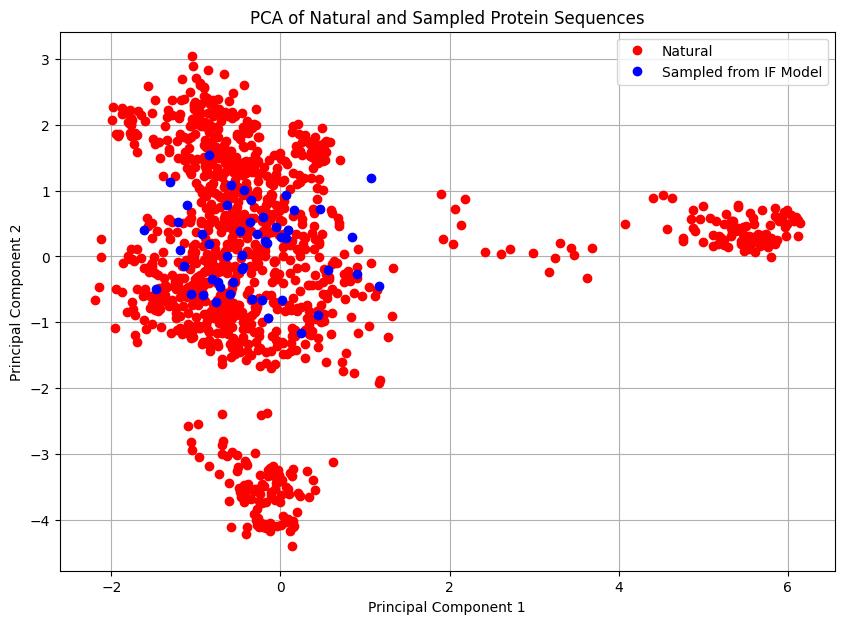

In [84]:
'Write here your code to generate new sequences and plot them in green on top of the natural sequences in the first 2 principal components of the PCA'

sample_seq = generate_sequences(h, J, 50)

pca_2d = PCA(n_components=2)
pca_nat_2d = pca_2d.fit_transform(onehot_nat)
pca_sampled_2d = pca_2d.transform(sample_seq)

plt.figure(figsize=(10, 7))
plt.plot(pca_nat_2d[:, 0], pca_nat_2d[:, 1], 'ro', label='Natural')
plt.plot(pca_sampled_2d[:, 0], pca_sampled_2d[:, 1], 'bo', label='Sampled from IF Model')
plt.title('PCA of Natural and Sampled Protein Sequences')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid()
plt.show()

# Exercise 3: Restricted Boltzmann Machine (RBM)

The Boltzmann Machine implemented in the previous excercise captures pairwise correlations, but real protein sequences exhibit higher-order interactions.

In this exercise, you will implement a Restricted Boltzmann Machine (RBM) to model the protein sequences. The RBM can potentially capture higher-order interactions between amino acid positions through its hidden units.


#### RBM Overview

**Architecture:**

An RBM consists of two layers:
- A visible layer $\mathbf{v}$ representing the input data (protein sequences in one-hot encoding). Each visible unit corresponds to a position in the protein sequence. Each position can take one of n_categories possible amino acids (represented using one-hot encoding).
- A hidden layer $\mathbf{h}$ that captures dependencies and features not explicitly present in the visible data. It consists of binary hidden units.

No intra-layer connections (i.e., units within a layer are not connected) are considered.


**Energy Function:**

The energy of a state in an RBM is defined as:

$$
E(v,h) = -\sum_{i=1}^{n_{visible}} \sum_{k=1}^{n_{categories}} v_{ik} b_{ik} - \sum_{j=1}^{n_{hidden}} h_{j} c_{j} - \sum_{i=1}^{n_{visible}} \sum_{j=1}^{n_{hidden}} \sum_{k=1}^{n_{categories}} v_{ik} h_{j} W_{jik}
$$

where:
- $v_{ik}$ are the visible units, in this case binary variables indicating amino acid k at position i.
- $h_j$ are the hidden units.
- $b_{ik}$ are biases for the visible units,
- $c_j$ are biases for the hidden units.
- $W_{jik}$ are the weights between the hidden and visible units (position-amino acid pairs).

**Probabilities:**

The conditional probabilities are:

- Hidden units given visible units:
  $$
  P(h_j = 1 | v) = \sigma\left(c_j + \sum_{i,k} v_{ik} W_{jik}\right)
  $$
- Visible units given hidden units:
  $$
  P(v_i = k | h) = \frac{\exp(b_{ik} + \sum_{j} h_j W_{jik})}{\sum_{k'} \exp(b_{ik'} + \sum_{j} h_j W_{jik'})}
  $$

where $\sigma(x)$ is the logistic sigmoid function.


**Dealing with Categorical Data in RBMs:**
- Since each position can only have one amino acid, we use a **multinomial RBM** with a softmax distribution over amino acids at each position. This is used when the visible units represent categorical data, just like in our case.

- The RBM is trained using Contrastive Divergence to approximate the likelihood gradient.


**Training with Contrastive Divergence:**

- Initialize parameters randomly.
- For each data sample:
  1. Compute the probabilities and sample from $P(h | v)$ for the hidden units.
  2. Reconstruct the visible units by sampling from $P(v | h)$.
  3. Sample again from $P(h | v)$ using the reconstructed visible units.
  4. Update the weights and biases using the differences between the samples obtained from the data and the reconstructed samples.

#### Implementation Steps and Tasks to do below:

1. **Data Preparation:**
   Convert the protein sequences into a suitable format (one-hot encoded vectors) and create a DataLoader to manage batches.

2. **Define the RBM Architecture:**
   Implement the `MultinomialRBM` class using PyTorch, including methods for sampling and calculating the free energy.

3. **Training:**
   Use the Contrastive Divergence algorithm to train the RBM. Adjust hyperparameters such as the number of hidden units, learning rate, and number of epochs based on validation performance. Use the the natural protein sequences.

4. **Generate New Sequences:**
   After training, use the RBM to generate new protein sequences. This involves initializing the visible layer randomly and running a Gibbs sampling chain to obtain samples from the model's distribution.

5. **Analysis:**
   Project both the original and generated sequences using PCA to visually assess the quality of the learned model. Compare these projections to evaluate how well the RBM captures the structure of the protein sequence space.

#### Expected Outcome:

With a properly tuned RBM, you should see that the generated sequences are distributed in PCA space similarly to the natural sequences, potentially even more closely than the pairwise Potts model. This indicates that the RBM can capture more complex patterns and higher-order interactions present in the protein sequences.


**Hints:**
- Consider using a moderate number of hidden units (e.g., 500) as a starting point.
- Experiment with different learning rates and the number of Gibbs steps in Contrastive Divergence.
- Use `torch.einsum` for efficient tensor operations.

**Code Hints:**
- The provided `MultinomialRBM` class is a good reference for handling categorical data.
- Use `torch.sigmoid` for the  for hidden unit probabilities.
- Use `torch.softmax` for the visible units to ensure probabilities sum to 1 at each position.
- Implement the energy calculation using `torch.einsum` for efficient computation.


### Note before the excercise: 

In this excercise we are implementing a Multinomial Restricted Boltzmann Machine (RBM) to model protein sequences. Protein sequences consist of amino acids at each position, which are categorical variables. Therefore, we need an RBM that can handle multinomial (categorical) data rather than binary data. Indeed, standard RBMs are designed for binary data. When applied directly to one-hot encoded categorical data, they can struggle to capture the dependencies correctly.
Treating each category as an independent binary variable ignores the mutual exclusivity of categories in one-hot encoding (i.e., only one category can be active at a position).
This is why in the previous formulas we handle categorical data by using softmax units in the visible layer (the softmax function ensures that the probabilities over categories at each position sum to 1) and use a multinomial visible units (to respect the one-hot encoding).


In [92]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Assuming onehot_nat is the one-hot encoded data with shape (num_samples, L*q)
num_samples = onehot_nat.shape[0]
n_visible_positions = 96  # Length of the sequences (L)
n_categories = 20  # Number of amino acids (excluding gap) (q)

# Reshape data to (num_samples, n_visible_positions, n_categories)
onehot_nat_tensor = torch.tensor(onehot_nat, dtype=torch.float32)
onehot_nat_tensor = onehot_nat_tensor.view(num_samples, n_visible_positions, n_categories)
#Data Reshaping: The data is reshaped to a 3D tensor where each sample is of shape (n_visible_positions, n_categories), representing the one-hot encoding at each position.

In [102]:
class MultinomialRBM(nn.Module):
    def __init__(self, n_visible_positions, n_hidden, n_categories):
        super(MultinomialRBM, self).__init__()
        self.n_visible_positions = n_visible_positions
        self.n_hidden = n_hidden
        self.n_categories = n_categories

        # Initialize parameters
        # Weights: (n_hidden, n_visible_positions, n_categories)
        self.W = nn.Parameter(torch.randn(n_hidden, n_visible_positions, n_categories) * 0.01)
        # Visible biases: (n_visible_positions, n_categories)
        self.v_bias = nn.Parameter(torch.zeros(n_visible_positions, n_categories))
        # Hidden biases: (n_hidden)
        self.h_bias = nn.Parameter(torch.zeros(n_hidden))

    def free_energy(self, v):
        # v: (batch_size, n_visible_positions, n_categories)
        batch_size = v.size(0)
        # Compute visible biases term
        vbias_term = torch.einsum('bik,ik->b', v, self.v_bias)
        # Compute hidden units activation
        wx_b = torch.einsum('bik,hik->bh', v, self.W) + self.h_bias   # (batch_size, n_hidden)
        hidden_term = torch.sum(torch.log1p(torch.exp(wx_b)), dim=1)
        free_energy = -vbias_term - hidden_term
        return free_energy

    def sample_h(self, v):
        # v: (batch_size, n_visible_positions, n_categories)
        wx_b = torch.einsum('bik,hik->bh', v, self.W) + self.h_bias 
        h_prob = torch.sigmoid(wx_b)
        h_sample = torch.bernoulli(h_prob)
        return h_prob, h_sample

    def sample_v(self, h):
        # h: (batch_size, n_hidden)
        wx_b = torch.einsum('bh,hik->bik', h, self.W) + self.v_bias  # (batch_size, n_visible_positions, n_categories)
        # Apply softmax over categories at each position
        v_prob = torch.softmax(wx_b, dim=2)
        # Sample from the multinomial distribution
        v_sample = torch.zeros_like(v_prob)
        for i in range(self.n_visible_positions):
            probs = v_prob[:, i, :]  # (batch_size, n_categories)
            samples = torch.multinomial(probs, num_samples=1).squeeze(-1)  # (batch_size,)
            # Convert one-hot tensor to float before assignment
            v_sample[range(h.size(0)), i, :] = torch.nn.functional.one_hot(samples, num_classes=self.n_categories).float()
        return v_prob, v_sample

    def contrastive_divergence(self, v0, k=1):
        vk = v0.clone()
        for _ in range(k):
            h_prob, h_sample = self.sample_h(vk)
            v_prob, vk = self.sample_v(h_sample)
        return v0, vk
''' 
### Explanation of the code above: 
MultinomialRBM Class: Inherits from nn.Module and defines the structure and parameters of the RBM.
Parameters:
Weights (self.W): Tensor of shape (n_hidden, n_visible_positions, n_categories).
Visible Biases (self.v_bias): Biases for the visible units, shape (n_visible_positions, n_categories).
Hidden Biases (self.h_bias): Biases for the hidden units, shape (n_hidden).

Free Energy: A scalar value representing the energy of the configuration, used to compute the loss.
Visible Bias Term: Computed using Einstein summation (torch.einsum) over the batch, positions, and categories.
Hidden Units Activation (wx_b): Computes the activation of hidden units given the visible units.
Hidden Term: Uses torch.log1p(torch.exp(wx_b)) for numerical stability when computing 
$\log(1+e^{w x_b}) $

Sampling Hidden Units (sample_h)
Activation (wx_b): Same as in the free energy calculation.
Probability (h_prob): The probability of the hidden units being active.
Sampling (h_sample): Samples the hidden units based on h_prob.

Sampling Visible Units
Activation (wx_b): Computes activations for the visible units given the hidden units.
Probability (v_prob): Softmax probabilities over the categories at each position.
Sampling (v_sample):
For each position, we sample from the multinomial distribution defined by v_prob.
The sampled indices are converted into one-hot vectors.
The float() conversion ensures that v_sample has the same data type as v_prob.

Contrastive Divergence
Contrastive Divergence (CD-k): An approximation to the gradient of the log-likelihood.
Gibbs Sampling: Alternates between sampling hidden units and visible units for k steps.
v0: Original data.
vk: Reconstructed data after k steps.


'''

<>:54: SyntaxWarning: invalid escape sequence '\l'
<>:54: SyntaxWarning: invalid escape sequence '\l'
/var/folders/ml/mckm5tb169sckcm9zfghvmm80000gn/T/ipykernel_1027/1551132718.py:54: SyntaxWarning: invalid escape sequence '\l'
  '''


' \n### Explanation of the code above: \nMultinomialRBM Class: Inherits from nn.Module and defines the structure and parameters of the RBM.\nParameters:\nWeights (self.W): Tensor of shape (n_hidden, n_visible_positions, n_categories).\nVisible Biases (self.v_bias): Biases for the visible units, shape (n_visible_positions, n_categories).\nHidden Biases (self.h_bias): Biases for the hidden units, shape (n_hidden).\n\nFree Energy: A scalar value representing the energy of the configuration, used to compute the loss.\nVisible Bias Term: Computed using Einstein summation (torch.einsum) over the batch, positions, and categories.\nHidden Units Activation (wx_b): Computes the activation of hidden units given the visible units.\nHidden Term: Uses torch.log1p(torch.exp(wx_b)) for numerical stability when computing \n$\\log(1+e^{w x_b}) $\n\nSampling Hidden Units (sample_h)\nActivation (wx_b): Same as in the free energy calculation.\nProbability (h_prob): The probability of the hidden units being

In [103]:
# Create DataLoader: Provides batches of data for training.
batch_size = 64
dataset = TensorDataset(onehot_nat_tensor)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

n_hidden = 500  # Adjust as needed

rbm = MultinomialRBM(n_visible_positions, n_hidden, n_categories)
optimizer = optim.Adam(rbm.parameters(), lr=0.001) #Optimizer: Adam optimizer is used for parameter updates.


n_epochs = 50  
k = 1  # Number of Gibbs sampling steps

for epoch in range(n_epochs):
    epoch_loss = 0
    for data in dataloader:
        v0 = data[0]
        v0 = v0.to(torch.float32)

        # Perform Contrastive Divergence
        v0, vk = rbm.contrastive_divergence(v0)

        # Compute loss (negative log-likelihood approximation)
        free_energy_v0 = rbm.free_energy(v0)
        free_energy_vk = rbm.free_energy(vk)
        loss = torch.mean(free_energy_v0) - torch.mean(free_energy_vk)
        epoch_loss += loss.item()

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f'Epoch {epoch+1}/{n_epochs}, Loss: {epoch_loss / len(dataloader)}')

'''
Training Loop:
Forward Pass: Perform contrastive divergence to obtain reconstructed data.
Loss Computation: The difference in free energy between the original and reconstructed data.
Backward Pass: Compute gradients via backpropagation.
Parameter Update: Update weights and biases using the optimizer.
Monitoring: Prints the loss at each epoch to monitor training progress.
'''


Epoch 1/50, Loss: 5.71793958875868
Epoch 2/50, Loss: -2.0529327392578125
Epoch 3/50, Loss: -10.028205023871529
Epoch 4/50, Loss: -18.726138644748264
Epoch 5/50, Loss: -25.53769090440538
Epoch 6/50, Loss: -32.856992933485245
Epoch 7/50, Loss: -41.042112562391495
Epoch 8/50, Loss: -49.819308810763886
Epoch 9/50, Loss: -60.49528333875868
Epoch 10/50, Loss: -71.1401875813802
Epoch 11/50, Loss: -85.40126546223958
Epoch 12/50, Loss: -98.87484402126736
Epoch 13/50, Loss: -115.23394775390625
Epoch 14/50, Loss: -129.86737399631076
Epoch 15/50, Loss: -146.6734585232205
Epoch 16/50, Loss: -162.07071940104166
Epoch 17/50, Loss: -178.71322292751736
Epoch 18/50, Loss: -194.5015869140625
Epoch 19/50, Loss: -211.8101806640625
Epoch 20/50, Loss: -226.97088283962674
Epoch 21/50, Loss: -244.51986694335938
Epoch 22/50, Loss: -261.11341688368054
Epoch 23/50, Loss: -277.49448649088544
Epoch 24/50, Loss: -294.29715304904516
Epoch 25/50, Loss: -311.37453206380206
Epoch 26/50, Loss: -326.67933485243054
Epoch 2

'\nTraining Loop:\nForward Pass: Perform contrastive divergence to obtain reconstructed data.\nLoss Computation: The difference in free energy between the original and reconstructed data.\nBackward Pass: Compute gradients via backpropagation.\nParameter Update: Update weights and biases using the optimizer.\nMonitoring: Prints the loss at each epoch to monitor training progress.\n'

In [104]:
def generate_samples(rbm, n_samples, gibbs_steps=100):
    samples = []
    # Initialize v with random one-hot vectors
    v = torch.zeros(1, rbm.n_visible_positions, rbm.n_categories, dtype=torch.float32)
    for i in range(rbm.n_visible_positions):
        idx = torch.randint(0, rbm.n_categories, (1,))
        v[0, i, idx] = 1.0  # Use 1.0 to ensure float type

    for _ in range(n_samples):
        vk = v.clone()
        for _ in range(gibbs_steps):
            h_prob, h_sample = rbm.sample_h(vk)
            v_prob, vk = rbm.sample_v(h_sample)
        samples.append(vk.squeeze(0).detach().numpy())
    return np.array(samples)

''' 
Initialization: Start with a random one-hot encoded sequence.
Gibbs Sampling: For a specified number of steps, alternate between sampling hidden units and visible units.
Collect Samples: After the Gibbs sampling, the visible units represent a sample from the model.
'''

' \nInitialization: Start with a random one-hot encoded sequence.\nGibbs Sampling: For a specified number of steps, alternate between sampling hidden units and visible units.\nCollect Samples: After the Gibbs sampling, the visible units represent a sample from the model.\n'

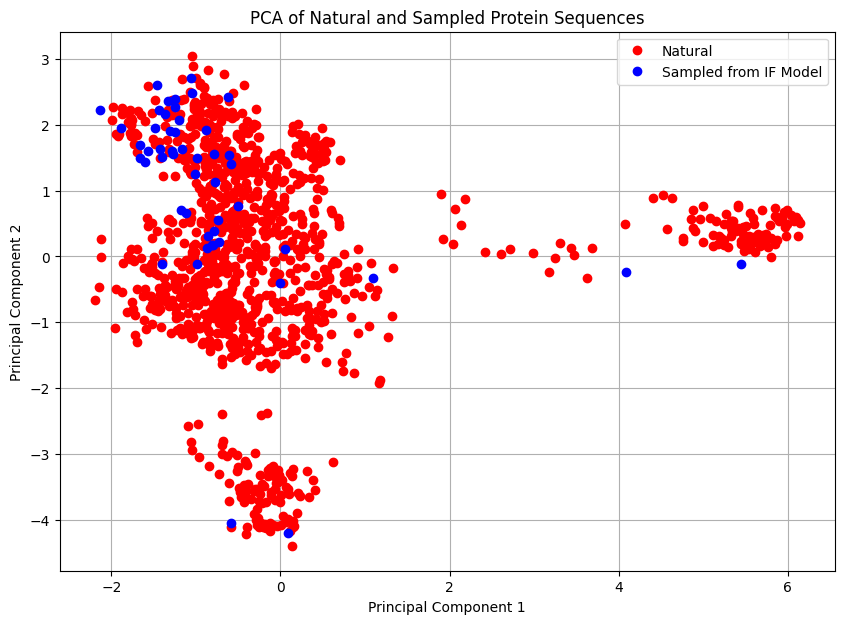

In [109]:
def flatten_samples(samples):
    num_samples = samples.shape[0]
    samples_flat = samples.reshape(num_samples, -1)
    return samples_flat

'Write your code here to generate RBM samples and project them onto the 2 PCA space with natural sequences'

sample_seq = generate_samples(rbm, 50)
sample_seq_flat = flatten_samples(sample_seq)

pca_2d = PCA(n_components=2)
pca_nat_2d = pca_2d.fit_transform(onehot_nat)
pca_sampled_2d = pca_2d.transform(sample_seq_flat)

plt.figure(figsize=(10, 7))
plt.plot(pca_nat_2d[:, 0], pca_nat_2d[:, 1], 'ro', label='Natural')
plt.plot(pca_sampled_2d[:, 0], pca_sampled_2d[:, 1], 'bo', label='Sampled from IF Model')
plt.title('PCA of Natural and Sampled Protein Sequences')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid()
plt.show()
